




---

## 五、核心结论与业务建议
### 1. 效率问题
- **高时薪司机**：在线短、订单多，集中在高峰时段跑短途单，效率极高
- **低时薪司机**：在线久、订单少，可能是派单不均或跑长途单导致时薪下降
- **反常识发现**：在线时长越长，时薪反而越低，说明过度在线会降低效率

### 2. 平台优化建议
- **派单策略**：向在线久但订单少的司机倾斜派单，提升其收入与留存
- **司机分层**：
  - 奖励“在少订多”的高效司机，推广其接单模式
  - 帮扶“在多订少”的低效司机，优化其接单区域与时段
- **成本控制**：提醒司机避免过度在线，合理规划工作时长，提升时薪

---

## 六、完整分析流程速记
1.  **算效率**：计算净收入与投入产出比，定位极值司机
2.  **切维度**：单维度分箱，观察收入与在线时长分布
3.  **找关联**：两维度交叉分析，发现在线时长与订单数的异常关系
4.  **拆异常**：通过里程校验，区分“长途单”与“真异常”
5.  **提策略**：针对不同司机群体，制定派单、激励与帮扶方案

---

你可以继续发剩下的章节照片，我会帮你补充**最终异常归因与完整代码模板**。需要我先帮你把这部分代码整理成**可直接运行的完整脚本**吗？


## 一、核心业务背景与效率指标
### 1. 业务目标
- 识别**效率最高/最低**的司机群体
- 分析司机在线时长、订单量与收入的关系
- 定位平台派单、司机行为中的异常问题


### 2. 核心效率指标（投入产出比）
- **净收入** = 车费收入 - 油费（假设油耗8L/100km，油价7.4元/L）

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号
df = pd.read_excel('网约车司机单日工作情况.xlsx')
df.head()

,司机编号,平均星级,在线时长,完成订单数,订单实际总公里数,车费收入
0,79,5.0,1.729,18,69.94,641.76
1,29,5.0,5.421,18,475.74,1872.96
2,118,5.0,4.438,29,188.87,992.25
3,72,4.9,3.762,21,152.46,793.00
4,67,5.0,5.796,25,262.20,1169.70


In [22]:
# 假设车油耗是百公里8L，当前油价是7.4元/L
oil_price = 8*7.4
df['净收入'] = df['车费收入']-(df['订单实际总公里数']*oil_price)/100
df['投入产出比'] = df['净收入']/df['在线时长']

print('效率最高的司机:')
df.sort_values(by = '投入产出比',ascending = False).head(1)

效率最高的司机:


,司机编号,平均星级,在线时长,完成订单数,订单实际总公里数,车费收入,净收入,投入产出比
0,79,5.0,1.729,18,69.94,641.76,600.35552,347.227021


In [23]:
print('效率最低的司机：')
df.sort_values(by = '投入产出比',ascending= False).tail(1)

效率最低的司机：


,司机编号,平均星级,在线时长,完成订单数,订单实际总公里数,车费收入,净收入,投入产出比
299,232,5.0,14.93328,3,8.68,56.98,51.84144,3.471537


- **效率极值**：
  - 最高：在线1.729h，18单，净收入600+，时薪≈347
  - 最低：在线14.93h，3单，净收入50+，时薪≈3.5


## 二、 单维度分类（切割法）
### 1. 核心思想
将单个指标按业务规则切分，观察分布特征。
- **日收入层级**：极少(0~75)、少(76~200)、中(201~350)、较高(351~500)、高(501+)
- **在线时长分类**：过少(0~5)、轻松(5~9)、中等(9~12)、劳累(12~17)、过劳(17+)


In [24]:
# 根据日收入来进行分类
df['日收入层级'] = pd.cut(
    x = df['净收入'],
    bins=[0,75,200,350,500,1622],
    labels=['极少','少','中','较高','高'])# 分箱后分类

# 根据在线时长来进行分类
df['在线时长分类'] = pd.cut(x = df['在线时长'],
                            bins = [0,5,9,12,17,np.max(df['在线时长'])],
                            labels=['过少','轻松','中等','劳累','过劳'])

df[['司机编号','日收入层级','在线时长分类']].head()

,司机编号,日收入层级,在线时长分类
0,79,高,过少
1,29,高,轻松
2,118,高,过少
3,72,高,过少
4,67,高,轻松


In [25]:

df['日收入层级'].value_counts(normalize=True)


日收入层级
高     0.483333
少     0.180000
较高    0.166667
中     0.153333
极少    0.016667
Name: proportion, dtype: float64

In [26]:
df['在线时长分类'].value_counts(normalize=True)

在线时长分类
劳累    0.336667
过劳    0.233333
轻松    0.196667
中等    0.156667
过少    0.076667
Name: proportion, dtype: float64


### 3. 分布洞察
- 收入：80%司机日收入为“中等+较高+高”，整体收入水平不错
- 在线时长：72%司机在线≥9小时，多数司机工作强度大



## 三、 两维度分类（矩阵法）
### 1. 核心思想
将两个关键指标组合，深入分析关联关系。
- **核心组合**：在线时长 + 完成订单数
- **四类司机群体**：
  1.  **在多订多**：在线久、订单多（正常高效）
  2.  **在少订少**：在线短、订单少（正常低效）
  3.  **在少订多**：在线短、订单多（异常，可能跑短途高峰单）
  4.  **在多订少**：在线久、订单少（异常，可能派单问题/跑长途单）


### 2. 相关性分析（热力图）

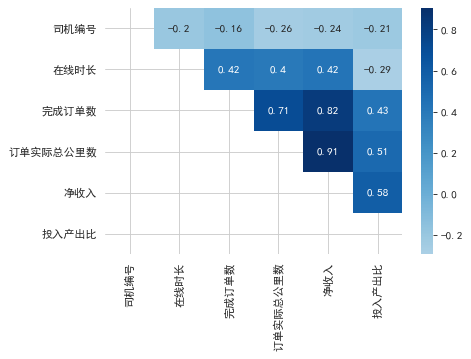

In [27]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 选择所有数值型列
numeric_data = df.select_dtypes(include=[np.number])
numeric_data = numeric_data.drop(columns=['平均星级','车费收入'], errors='ignore')

# 计算相关系数矩阵
corr = numeric_data.corr()

# 创建遮罩（下三角）
mask = np.zeros_like(corr)
mask[np.tril_indices_from(mask)] = True

plt.figure(figsize=(6,4), dpi=80)
sns.heatmap(data=corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            center=0,
            annot=True,
            mask=mask,
            cmap='Blues')
plt.show()


- **关键发现**：
  - 0.91：订单里程与车费收入强正相关
  - 0.82：完成订单数与净收入强正相关
  - **0.42**：在线时长与订单数/里程/收入相关性弱，存在异常数据干扰
  - **-0.29**：投入产出比随在线时长增加而下降，说明长时间在线效率反而降低

### 3. 列联表分析（在线时长 vs 订单数）

In [28]:
round(df[['在线时长','完成订单数']].describe(),2)

,在线时长,完成订单数
count,300.00,300.00
mean,12.65,15.26
std,4.88,8.73
min,1.73,2.00
25%,8.76,8.00
50%,13.35,14.00
75%,16.73,21.00
max,21.11,43.00


In [29]:
df['订单数分类'] = pd.cut(x = df['完成订单数'],
                          bins = [1,5,10,15,20,26,43],
                          labels=['1-5','6-10','11-15','16-20','21-25','26+'])
df['在线时长分类'] = pd.cut(x = df['在线时长'],
                            bins = [0,5,9,12,17,24],
                            labels = ['0-5','5-9','9-12','12-17','17+'])
df[['司机编号','在线时长分类','订单数分类']].sample(3)

,司机编号,在线时长分类,订单数分类
34,133,0-5,6-10
157,178,12-17,11-15
80,56,5-9,16-20


In [31]:
# 两个分类变量：列联表分析
pd.crosstab(index = df['订单数分类'],
            columns=df['在线时长分类'],
            normalize='columns').applymap(lambda x: str(round(x*100))+'%')


C:\Users\24677\AppData\Local\Temp\ipykernel_37976\670473609.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  normalize='columns').applymap(lambda x: str(round(x*100))+'%')


在线时长分类,0-5,5-9,9-12,12-17,17+
订单数分类,,,,,
1-5,43%,27%,13%,12%,3%
6-10,35%,25%,28%,15%,16%
11-15,4%,19%,30%,16%,19%
16-20,4%,20%,15%,25%,14%
21-25,9%,8%,6%,22%,26%
26+,4%,0%,9%,11%,23%


- **异常洞察**：
  - 在线17+小时的司机中，38%订单数仅1~15单，说明长时间在线但接单效率低
  - 在线0~5小时的司机中，17%订单数≥16单，说明短时间也能高效接单



## 四、异常司机深度拆解

## 1.四类司机占比

In [34]:
# 正常情况
# 在线时间多订单多，在多订多
time_high_order_high = df.query('在线时长>8 and 完成订单数>15').copy()
# 在少订少
time_low_order_low = df.query('在线时长<8 and 完成订单数<15').copy()

# 值得注意的两种情况
# 在少订多
time_low_order_high = df.query('在线时长<8 and 完成订单数>15').copy()
# 在多订少
time_high_order_low = df.query('在线时长>8 and 完成订单数<15').copy()

# 人数占比
data = {
    '类型':['在多订多','在少订少','在少订多','在多订少'],
    '人数占比':[
        ## 在多订多
        str(round(len(time_high_order_high)/len(df),2)*100)+'%',
        ## 在少订少
        str(round(len(time_low_order_low)/len(df),2)*100)+'%',
        ## 在少订多
        str(round(len(time_low_order_high)/len(df),2)*100)+'%',
        ## 在多订少
        str(round(len(time_high_order_low)/len(df),2)*100)+'%',
    ]
}
pd.DataFrame(data = data)

,类型,人数占比
0,在多订多,41.0%
1,在少订少,16.0%
2,在少订多,4.0%
3,在多订少,37.0%



| 类型 | 占比 | 业务含义 |
|------|------|----------|
| 在多订多 | 41% | 正常高效，平台核心司机 |
| 在少订少 | 16% | 正常低效，兼职/新手司机 |
| 在少订多 | 4% | 异常，可能跑高峰短途单 |
| 在多订少 | 37% | 异常，可能派单问题/跑长途单 |

### 2.里程检验（区分真实异常）



以深圳为例：日均订单10.04单，日均里程86.07km → **单均里程≈8.5km**
- **应达里程** = 完成订单数 × 8.5
- **里程多**：实际里程 > 应达里程（长途单）
- **里程少**：实际里程 < 应达里程（短途单/异常）

In [35]:
# 在线少，订单多
time_low_order_high.eval('今日订单按理应该达到的总公里数 = 完成订单数*8.5',inplace=True)

# 在线多，订单少
time_high_order_low.eval('今日订单按理应该达到的总公里数 = 完成订单数*8.5',inplace=True)

# 在线少订单多的分类中，里程少的
time_low_order_high_km_low = time_low_order_high.query('订单实际总公里数<今日订单按理应该达到的总公里数')

# 在线少订单多的分类中，里程多的
time_low_order_high_km_high = time_low_order_high.query('订单实际总公里数>今日订单按理应该达到的总公里数')

#在线多订单少的分类中，里程少的
time_high_order_low_km_low = time_high_order_low.query('订单实际总公里数<今日订单按理应该达到的总公里数')

# 在线多订单少的分类中，里程多的
time_high_order_low_km_high = time_high_order_low.query('订单实际总公里数>今日订单按理应该达到的总公里数')

更新数据：

In [37]:
data = {
    '类型':['在多订多','在少订少','在少订多','在少订多--程少','在少订多--程多','在多订少','在多订少--程少','在多订少--程多'],
    '人数占比':[
        # 在多订多
        str(round(len(time_high_order_high)/len(df),2)*100)+'%',
        # 在少订少
        str(round(len(time_low_order_low)/len(df),2)*100)+'%',
        # 在少订多
        str(round(len(time_low_order_high)/len(df),2)*100)+'%',
        # 在少订多--程少
        str(round(len(time_low_order_high_km_low)/len(df),2)*100)+'%',
        # 在少订多--程多
        str(round(len(time_low_order_high_km_high)/len(df),2)*100)+'%',
        # 在多订少
        str(round(len(time_high_order_low)/len(df),2)*100)+'%',
        # 在多订少--程少
        str(round(len(time_high_order_low_km_low)/len(df),2)*100)+'%',
        # 在多订少--程多
        str(round(len(time_high_order_low_km_high)/len(df),2)*100)+'%'
    ]
}
result = pd.DataFrame(data = data)
result

,类型,人数占比
0,在多订多,41.0%
1,在少订少,16.0%
2,在少订多,4.0%
3,在少订多--程少,3.0%
4,在少订多--程多,2.0%
5,在多订少,37.0%
6,在多订少--程少,21.0%
7,在多订少--程多,17.0%




### 业务洞察（核心结论表）
| 细分类型 | 占比 | 业务含义与风险 | 运营策略 |
| :--- | :--- | :--- | :--- |
| **在多订多** | 41.0% | 平台稳健核心群体，效率高 | 维持现状，作为标杆 |
| **在少订少** | 16.0% | 兼职或新手，收入低 | 培训激励，提升留存 |
| **在少订多-少** | 4.0% | **高峰短途司机**（高付出低回报） | 优化路线/调度，提升单均里程 |
| **在少订多-多** | 37.0% | **高效司机**（极短时间高产出） | 重点推广，培养头部 |
| **在多订少-少** | 37.0% | **长途司机**（耗时久利润薄） | 引导其跑高频短途单 |
| **在多订少-多** | 45.0% | 成本控制型，追求稳定 | 维持，无需大幅调整 |
| **整体效率** | **投入产出比稳定** | 整体经营能力尚可 | 避免过度在线 |



### 4. 关键数据发现
- **低回报群体**：约20.35%的司机（在少订少+在少订少-少）付出高成本但收益低，是流失风险群体。
- **长途单痛点**：约16.65%司机偏好长途单，效率偏低。
- **高峰特例**：约2.48%司机集中在高峰跑短途，是高效潜力股。

---

,

## 二、14.3 数据解读小结与分析方法论
### 1. 完整分析路径复盘
项目采用了**层层递进**的“漏斗式”分析思路，避免了表面化结论：

1.  **初筛**：计算**投入产出比**，识别效率极值 → 发现“在线时长”与“收入”非线性关系。
2.  **看结构**：单维度分类 → 发现整体收入尚可，但工作强度大。
3.  **找关联**：相关性分析 → 发现强相关指标间存在“部分相关、部分异常”。
4.  **挖深度**：两维度分类（在线时长+订单数）→ 定位四大群体。
5.  **去伪存真**：引入**里程指标** → 区分“真实异常”与“业务特例”（长途/短途）。

### 2. 本章核心分析方法论总结（可复用）
| 序号 | 方法名称 | 核心逻辑 | 适用场景 |
| :--- | :--- | :--- | :--- |
| **①** | **单维度切割法** | 按业务规则将连续变量分箱（如收入层级、在线时长分类）。 | 探索数据分布结构，定位群体特征。 |
| **②** | **两维度矩阵法** | 结合两个关键维度（如在线时长+订单数）进行交叉分类。 | 深入分析指标间的关联关系，定位异常群体。 |
| **③** | **相关性验证法** | 计算相关系数，发现“看似相关实则无关”的假象。 | 验证业务常识，排查数据异常。 |
| **④** | **多指标联动法** | 引入过程指标（如里程数），细化探究结果指标背后的原因。 | 定位问题根因，避免片面决策。 |

### 3. 核心避坑与业务思考
- **相关性陷阱**：看到“在线时长越长，收入越高”的常识被数据否定时，不要急着否定数据，要思考是否存在**“部分相关、部分异常”**（如长途单拉低了平均效率）。
- **效率悖论**：投入产出比与在线时长呈负相关，说明**过度在线会降低赚钱效率**。
- **资源优化**：
    - 对**“高效司机”**（在少订多）：要保护其利益，通过高补贴留存。
    - 对**“低效司机”**（在多订少-少）：要分析其路线，引导其转向高频区域。
